# Scientific Workflow for Extracting Viscosity from Rotational Drag vs Gap Height Data

**Purpose** — Rigorous, publication-quality rheological analysis of rotational drag
($T/\Omega$) as a function of cone–plate / parallel-gap separation $h$.

**Theoretical context.** For a Newtonian fluid in a narrow gap, the resisting torque on a
rotating disk scales approximately as

$$\frac{T}{\Omega} \;=\; \frac{A}{h} + B,$$

with $A \propto \mu R^4$ (viscosity $\mu$, plate radius $R$) and $B$ a baseline / parasitic
drag term. Real measurements deviate from this pure $1/h$ law due to:

- finite-size / edge effects,
- slip, wall roughness, compliance, steric layers,
- gap-zero uncertainty (the absolute contact point is not exactly known),
- shear-thinning / yield-stress / viscoelastic behaviour.

This notebook implements a full modular pipeline:

1. data import & preprocessing
2. log–log scaling diagnosis
3. candidate physical models (hyperbolic, regularized, generalized power, saturation)
4. direct physical-space nonlinear fits
5. robust / weighted / orthogonal-distance fits
6. residual diagnostics
7. model comparison (AIC, BIC, CV)
8. low-gap sensitivity (point-removal stability)
9. uncertainty quantification (bootstrap, optional MCMC)
10. final scientific interpretation
11. publication-quality figures
12. optional advanced regime analysis

All steps are wrapped in reusable helper functions and produce exportable
CSV / SVG / PNG artefacts.


## 0. Environment & global configuration

Imports, plot style, output directories.

In [18]:
from __future__ import annotations

import os
import json
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy import optimize, stats, odr
from sklearn.model_selection import KFold
import statsmodels.api as sm

try:
    import lmfit  # optional but preferred for richer fits
    HAS_LMFIT = True
except Exception:
    HAS_LMFIT = False

try:
    import emcee  # optional Bayesian
    HAS_EMCEE = True
except Exception:
    HAS_EMCEE = False

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Publication-quality plot defaults
rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.6,
    "figure.figsize": (7.0, 4.4),
})

PALETTE = plt.get_cmap("viridis")

FIG_DIR = Path("figures_rheology"); FIG_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("outputs_rheology"); OUT_DIR.mkdir(exist_ok=True)

def save_fig(fig, name: str):
    for ext in ("png", "svg"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    return fig

print(f"lmfit available : {HAS_LMFIT}")
print(f"emcee available : {HAS_EMCEE}")
print(f"Figures dir     : {FIG_DIR.resolve()}")
print(f"Outputs dir     : {OUT_DIR.resolve()}")


lmfit available : False
emcee available : False
Figures dir     : C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\results\Auto-runs\figures_rheology
Outputs dir     : C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\results\Auto-runs\outputs_rheology


## USER INPUT SECTION

Define the dataset path, units, and the columns that map to the canonical variables
`h` (gap height) and `T_over_RPM` (= $T/\Omega$).

The provided dataset `height_normalized.csv` is in **wide form**: one `Height` column plus
many viscosity-sample columns named like `12.5kcp_14.576_torque_%_rpm_3.5`. Each sample
column holds the torque-per-RPM (in %/RPM units) at the corresponding gap height.

We therefore reshape it into a tidy long form with one row per `(sample, h)` pair.
You may also point `DATA_PATH` to your own CSV and override `H_COL` / `Y_COL` / `RPM_COL`
if your file already has columns in canonical form.


In [19]:
# ---- USER-CONFIGURABLE BLOCK -----------------------------------------------
DATA_PATH = Path("height_normalized.csv")     # <- change to your file

# Canonical columns (used when the file is already tidy):
H_COL   = "h_mm"          # gap height
Y_COL   = "T_over_RPM"    # torque / RPM
RPM_COL = "RPM"           # optional
T_COL   = "Torque"        # optional

# Units
H_UNIT = "mm"                  # 'mm' or 'um'
Y_UNIT = "% / RPM"             # arbitrary string; for axis labels only

# If True we reshape the wide `height_normalized.csv` into long form.
WIDE_FORMAT = True

# Which sample(s) to analyze in detail. Use None to analyse ALL samples in a loop
# at the end, or a string like '12.5kcp' to analyse a specific viscosity grade.
FOCUS_SAMPLE = "12.5kcp"
# ----------------------------------------------------------------------------


## 1. Data import and preprocessing

**Why this matters.** $T/\Omega$ vs $h$ encodes the viscosity through the slope of the
hyperbolic divergence as $h\to 0$. Small-gap data points are simultaneously the most
informative and the most error-prone: a 10 µm uncertainty on a 50 µm gap produces a
20 % uncertainty on $1/h$. We therefore:

- import the CSV defensively,
- standardize units to mm,
- drop NaN / non-positive heights,
- sort by `h`,
- optionally average replicate heights.

Helper functions: `validate_columns`, `load_data`, `preprocess_data`, `wide_to_long`.


In [20]:
def validate_columns(df: pd.DataFrame, required: Sequence[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}. Available: {list(df.columns)}")

def wide_to_long(df: pd.DataFrame, h_col: str = "Height") -> pd.DataFrame:
    """Reshape the project-specific wide CSV to tidy long form.

    Column names like '12.5kcp_14.576_torque_%_rpm_3.5' are parsed into
    sample label, nominal torque %, and RPM.
    """
    validate_columns(df, [h_col])
    long_rows = []
    for col in df.columns:
        if col == h_col:
            continue
        # Parse: '<label>kcp_<torque%>_torque_%_rpm_<rpm>'
        parts = col.split("_")
        try:
            label = parts[0]                          # '12.5kcp'
            torque_pct = float(parts[1])              # nominal torque %
            rpm = float(parts[-1])                    # rpm at hit-point
        except Exception:
            label, torque_pct, rpm = col, np.nan, np.nan
        sub = pd.DataFrame({
            "sample": label,
            "h_mm": df[h_col].values,
            "T_over_RPM": df[col].values,
            "RPM_nominal": rpm,
            "Torque_pct_hit": torque_pct,
        })
        long_rows.append(sub)
    return pd.concat(long_rows, ignore_index=True)

def load_data(path: Path | str, wide: bool = WIDE_FORMAT) -> pd.DataFrame:
    df = pd.read_csv(path)
    if wide:
        df = wide_to_long(df, h_col=df.columns[0])
    return df

def preprocess_data(df: pd.DataFrame,
                    h_col: str = "h_mm",
                    y_col: str = "T_over_RPM",
                    h_unit: str = "mm",
                    drop_zero_h: bool = False) -> pd.DataFrame:
    """Standardize units (→ mm), clean NaN / non-finite, sort, deduplicate."""
    validate_columns(df, [h_col, y_col])
    df = df.copy()
    if h_unit == "um":
        df[h_col] = df[h_col] / 1000.0
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[h_col, y_col])
    if drop_zero_h:
        df = df[df[h_col] > 0]
    else:
        # avoid log(0) downstream by clipping a tiny epsilon for log analyses only
        df = df[df[h_col] >= 0]
    df = df.sort_values(h_col).reset_index(drop=True)
    return df

# --- Run import ----------------------------------------------------------
raw = load_data(DATA_PATH, wide=WIDE_FORMAT)
print(f"Loaded {len(raw):,} rows, samples = {raw['sample'].nunique()}")
display(raw.head())

# Tidy + units
tidy = preprocess_data(raw, h_col="h_mm", y_col="T_over_RPM", h_unit=H_UNIT, drop_zero_h=True)
print(f"After preprocessing: {len(tidy):,} rows across {tidy['sample'].nunique()} samples")


Loaded 713 rows, samples = 23


,sample,h_mm,T_over_RPM,RPM_nominal,Torque_pct_hit
0,1kcp,0.00,1.535177,47.0,1.073
1,1kcp,0.02,1.393901,47.0,1.073
2,1kcp,0.04,1.318369,47.0,1.073
3,1kcp,0.06,1.256525,47.0,1.073
4,1kcp,0.08,1.196525,47.0,1.073


After preprocessing: 425 rows across 23 samples


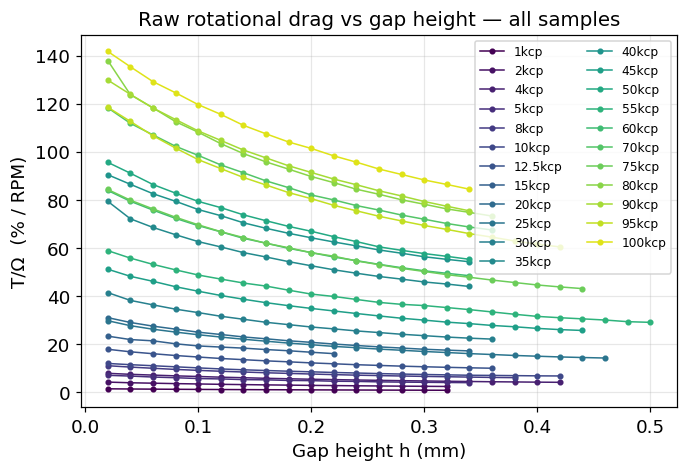

Focus sample = 12.5kcp (18 points)


,sample,h_mm,T_over_RPM,RPM_nominal,Torque_pct_hit
0,12.5kcp,0.02,17.844762,3.5,14.576
1,12.5kcp,0.04,16.795238,3.5,14.576
2,12.5kcp,0.06,16.000000,3.5,14.576
3,12.5kcp,0.08,15.248571,3.5,14.576
4,12.5kcp,0.10,14.620000,3.5,14.576


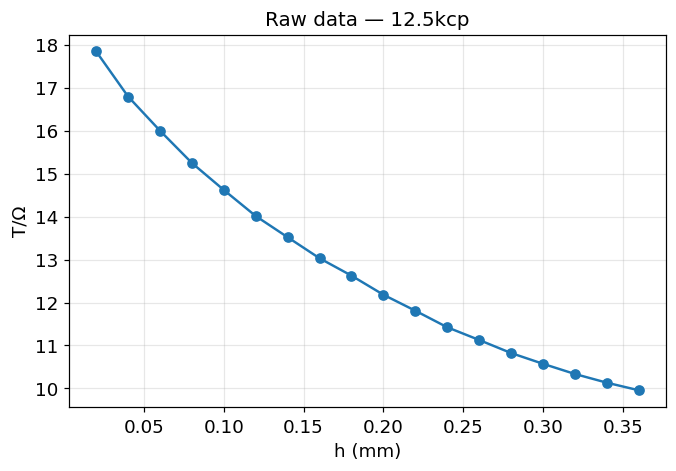

In [21]:
# Quick raw visualization across all samples
fig, ax = plt.subplots()
samples = sorted(tidy["sample"].unique(), key=lambda s: float(s.replace("kcp", "")))
colors = PALETTE(np.linspace(0, 0.95, len(samples)))
for c, s in zip(colors, samples):
    sub = tidy[tidy["sample"] == s]
    ax.plot(sub["h_mm"], sub["T_over_RPM"], "o-", ms=3, lw=1, color=c, label=s)
ax.set_xlabel("Gap height h (mm)")
ax.set_ylabel(f"T/Ω  ({Y_UNIT})")
ax.set_title("Raw rotational drag vs gap height — all samples")
ax.legend(ncol=2, fontsize=8, loc="upper right")
save_fig(fig, "01_raw_all_samples"); plt.show()

# Focused sample
focus = tidy[tidy["sample"] == FOCUS_SAMPLE].reset_index(drop=True)
print(f"Focus sample = {FOCUS_SAMPLE} ({len(focus)} points)")
display(focus.head())

fig, ax = plt.subplots()
ax.plot(focus["h_mm"], focus["T_over_RPM"], "o-", color="C0")
ax.set_xlabel("h (mm)"); ax.set_ylabel("T/Ω")
ax.set_title(f"Raw data — {FOCUS_SAMPLE}")
save_fig(fig, "01_raw_focus"); plt.show()


## 2. Initial scaling diagnosis (log–log analysis)

If $T/\Omega \sim h^{-n}$ then $\log(T/\Omega) = -n\log h + \text{const}$.
A global log–log linear fit gives one exponent $n$; a **local** moving-window slope or
numerical derivative reveals whether the apparent exponent **changes** with $h$ — a
hallmark of regularization (finite $h_0$), slip layers, or shear-thinning crossover.

Helpers: `fit_loglog_scaling`, `compute_local_slope`, `plot_loglog_analysis`.


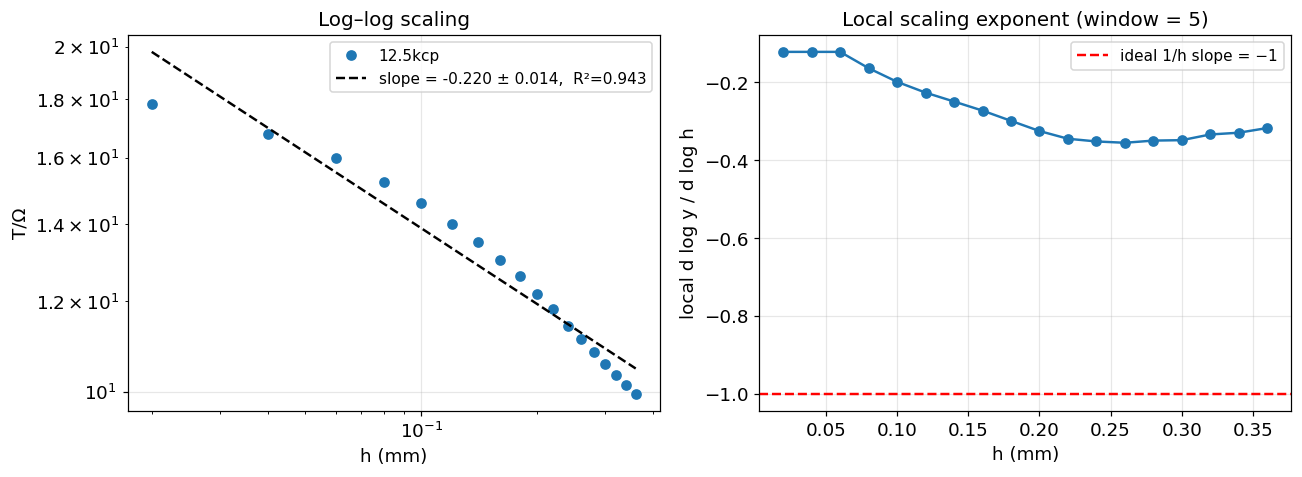

Global scaling exponent  : -0.2202  (95% CI -0.247, -0.194)
R²                       : 0.9429
→ |slope| < 1: divergence is *weaker* than pure 1/h ⇒ likely regularization (finite h0) or slip.


In [22]:
def fit_loglog_scaling(h, y):
    """Linear regression on log(y) = a*log(h) + b. Returns slope, intercept, stderr, R²."""
    h = np.asarray(h, float); y = np.asarray(y, float)
    m = (h > 0) & (y > 0)
    x, z = np.log(h[m]), np.log(y[m])
    res = stats.linregress(x, z)
    return {
        "slope": res.slope, "intercept": res.intercept,
        "stderr_slope": res.stderr, "r2": res.rvalue ** 2,
        "ci95_slope": (res.slope - 1.96 * res.stderr, res.slope + 1.96 * res.stderr),
    }

def compute_local_slope(h, y, window: int = 5):
    """Moving-window OLS slope in log–log space. Window in number of points."""
    h = np.asarray(h, float); y = np.asarray(y, float)
    m = (h > 0) & (y > 0)
    h, y = h[m], y[m]
    n = len(h)
    slopes = np.full(n, np.nan)
    for i in range(n):
        lo = max(0, i - window // 2); hi = min(n, lo + window)
        if hi - lo < 3: continue
        s = stats.linregress(np.log(h[lo:hi]), np.log(y[lo:hi])).slope
        slopes[i] = s
    return h, slopes

def plot_loglog_analysis(h, y, label="data"):
    res = fit_loglog_scaling(h, y)
    h_l, slopes = compute_local_slope(h, y, window=5)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    # Log-log fit
    ax = axes[0]
    ax.loglog(h, y, "o", label=label)
    hh = np.logspace(np.log10(h.min()), np.log10(h.max()), 100)
    yy = np.exp(res["intercept"]) * hh ** res["slope"]
    ax.loglog(hh, yy, "--", color="k",
              label=f"slope = {res['slope']:.3f} ± {res['stderr_slope']:.3f},  R²={res['r2']:.3f}")
    ax.set_xlabel("h (mm)"); ax.set_ylabel("T/Ω"); ax.set_title("Log–log scaling")
    ax.legend()

    # Local slope
    ax = axes[1]
    ax.plot(h_l, slopes, "o-")
    ax.axhline(-1, color="r", ls="--", label="ideal 1/h slope = −1")
    ax.set_xlabel("h (mm)"); ax.set_ylabel("local d log y / d log h")
    ax.set_title("Local scaling exponent (window = 5)")
    ax.legend()
    plt.tight_layout()
    return fig, res

fig, ll = plot_loglog_analysis(focus["h_mm"].values, focus["T_over_RPM"].values, label=FOCUS_SAMPLE)
save_fig(fig, "02_loglog_focus"); plt.show()

print(f"Global scaling exponent  : {ll['slope']:.4f}  (95% CI {ll['ci95_slope'][0]:.3f}, {ll['ci95_slope'][1]:.3f})")
print(f"R²                       : {ll['r2']:.4f}")
if ll["slope"] > -0.7:
    print("→ |slope| < 1: divergence is *weaker* than pure 1/h ⇒ likely regularization (finite h0) or slip.")
elif ll["slope"] < -1.3:
    print("→ |slope| > 1: divergence stronger than 1/h ⇒ possible squeeze-film / lubrication regime.")
else:
    print("→ slope ≈ −1: behaviour consistent with classical 1/h hyperbolic drag.")


## 3. Physical model definitions

We compare four candidate models with progressively richer structure:

| Model | Form | Parameters | Comment |
|---|---|---|---|
| **Hyperbolic** | $A/h + B$ | $A, B$ | classical Newtonian limit |
| **Regularized hyperbola** | $A/(h+h_0) + B$ | $A, h_0, B$ | $h_0$ absorbs zero-gap offset / slip layer |
| **Generalized power** | $A/(h+h_0)^n + B$ | $A, h_0, n, B$ | flexible exponent — captures squeeze-film or sub-hyperbolic regimes |
| **Saturation** | $A\,(1 - e^{-h_c/h}) + B$ | $A, h_c, B$ | bounded near $h\to 0$ |

Physical meaning:
- $A$ ∝ effective viscosity × geometry factor.
- $h_0$ ≈ effective contact offset (slip length + asperity height + gap-zero error).
- $n$ deviation from 1 indicates non-classical lubrication or shear-thinning.
- $B$ baseline / parasitic drag (bearings, air).


In [23]:
def hyperbolic_model(h, A, B):
    return A / np.asarray(h) + B

def regularized_model(h, A, h0, B):
    return A / (np.asarray(h) + h0) + B

def generalized_powerlaw_model(h, A, h0, n, B):
    return A / (np.asarray(h) + h0) ** n + B

def saturation_model(h, A, hc, B):
    h = np.asarray(h, float)
    with np.errstate(divide="ignore"):
        return A * (1.0 - np.exp(-hc / np.where(h > 0, h, np.nan))) + B

MODELS: Dict[str, dict] = {
    "hyperbolic":   dict(func=hyperbolic_model,
                         p0=lambda h, y: [y.max() * h.min(), y.min()],
                         bounds=([0, -np.inf], [np.inf, np.inf]),
                         pnames=["A", "B"]),
    "regularized":  dict(func=regularized_model,
                         p0=lambda h, y: [y.max() * h.min(), 0.01, y.min()],
                         bounds=([0, 0, -np.inf], [np.inf, h.max() if False else np.inf, np.inf]),
                         pnames=["A", "h0", "B"]),
    "gen_power":    dict(func=generalized_powerlaw_model,
                         p0=lambda h, y: [y.max() * h.min(), 0.01, 1.0, y.min()],
                         bounds=([0, 0, 0.2, -np.inf], [np.inf, np.inf, 3.0, np.inf]),
                         pnames=["A", "h0", "n", "B"]),
    "saturation":   dict(func=saturation_model,
                         p0=lambda h, y: [y.max(), 0.05, y.min()],
                         bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
                         pnames=["A", "hc", "B"]),
}
print("Defined models:", list(MODELS))


Defined models: ['hyperbolic', 'regularized', 'gen_power', 'saturation']


## 4. Direct physical-space fitting

Fitting in the **original** $(h, T/\Omega)$ space — not in log or reciprocal space —
preserves the Gaussian error structure of the measurement and avoids transforming
heteroscedastic noise into a biased estimator. We use `scipy.optimize.curve_fit`
(Levenberg–Marquardt with bounds) with sensible initial guesses and bounds.

Helpers: `fit_model`, `predict_model`, `summarize_fit`.


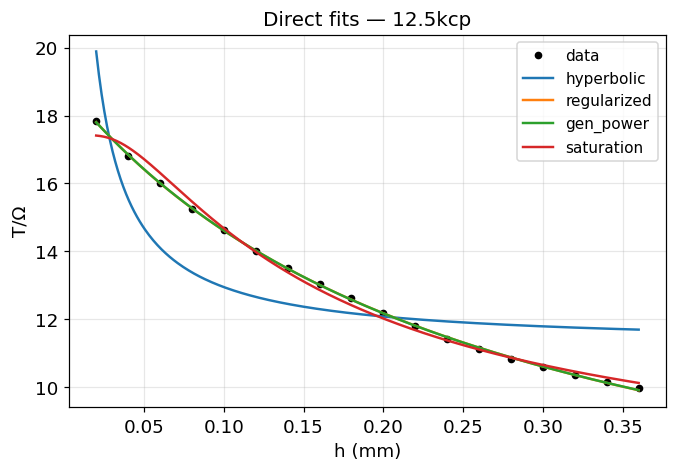


>>> hyperbolic  (success=True)


,param,value,stderr,ci95_lo,ci95_hi
0,A,0.173684,0.028784,0.117266,0.230101
1,B,11.206625,0.427871,10.367999,12.045251



>>> regularized  (success=True)


,param,value,stderr,ci95_lo,ci95_hi
0,A,4.073240,0.135735,3.807198,4.339281
1,h0,0.261785,0.006597,0.248855,0.274714
2,B,3.350670,0.163545,3.030122,3.671218



>>> gen_power  (success=True)


,param,value,stderr,ci95_lo,ci95_hi
0,A,3.726508,1.511599,0.763773,6.689243
1,h0,0.283849,0.110281,0.067699,0.499999
2,n,1.109378,0.545610,0.039983,2.178774
3,B,3.831233,2.167168,-0.416415,8.078882



>>> saturation  (success=True)


,param,value,stderr,ci95_lo,ci95_hi
0,A,10.645047,0.254707,10.145821,11.144272
1,hc,0.135474,0.007900,0.119990,0.150958
2,B,6.778491,0.286973,6.216025,7.340957


In [24]:
@dataclass
class FitResult:
    name: str
    popt: np.ndarray
    pcov: np.ndarray
    pnames: List[str]
    func: Callable
    h: np.ndarray
    y: np.ndarray
    sigma: Optional[np.ndarray] = None
    method: str = "lm"
    success: bool = True
    message: str = ""

    @property
    def perr(self) -> np.ndarray:
        return np.sqrt(np.diag(self.pcov)) if self.pcov is not None else np.full_like(self.popt, np.nan)

    def predict(self, h):
        return self.func(np.asarray(h), *self.popt)

    @property
    def residuals(self):
        return self.y - self.predict(self.h)

    def as_series(self):
        return pd.Series({**{n: v for n, v in zip(self.pnames, self.popt)},
                          **{f"{n}_se": s for n, s in zip(self.pnames, self.perr)},
                          "method": self.method})

def fit_model(name: str, h, y, sigma=None, p0=None, bounds=None, method: str = "trf") -> FitResult:
    spec = MODELS[name]
    h = np.asarray(h, float); y = np.asarray(y, float)
    if p0 is None: p0 = spec["p0"](h, y)
    if bounds is None: bounds = spec["bounds"]
    try:
        popt, pcov = optimize.curve_fit(spec["func"], h, y, p0=p0, sigma=sigma,
                                        absolute_sigma=sigma is not None,
                                        bounds=bounds, method=method, maxfev=20000)
        ok, msg = True, "ok"
    except Exception as e:
        popt = np.array(p0, float); pcov = np.full((len(p0), len(p0)), np.nan); ok, msg = False, str(e)
    return FitResult(name=name, popt=popt, pcov=pcov, pnames=spec["pnames"],
                     func=spec["func"], h=h, y=y, sigma=sigma, method=method,
                     success=ok, message=msg)

def predict_model(fr: FitResult, h):
    return fr.predict(h)

def summarize_fit(fr: FitResult) -> pd.DataFrame:
    rows = []
    for n, v, s in zip(fr.pnames, fr.popt, fr.perr):
        rows.append({"param": n, "value": v, "stderr": s,
                     "ci95_lo": v - 1.96 * s, "ci95_hi": v + 1.96 * s})
    return pd.DataFrame(rows)

# Fit all models on the focus sample
h_f = focus["h_mm"].values
y_f = focus["T_over_RPM"].values

fits: Dict[str, FitResult] = {name: fit_model(name, h_f, y_f) for name in MODELS}

# Overlay plot
fig, ax = plt.subplots()
ax.plot(h_f, y_f, "ko", label="data", ms=4)
hh = np.linspace(h_f.min(), h_f.max(), 400)
for (name, fr), c in zip(fits.items(), plt.get_cmap("tab10").colors):
    if fr.success:
        ax.plot(hh, fr.predict(hh), label=name, color=c)
ax.set_xlabel("h (mm)"); ax.set_ylabel("T/Ω")
ax.set_title(f"Direct fits — {FOCUS_SAMPLE}")
ax.legend(); save_fig(fig, "04_direct_fits"); plt.show()

for name, fr in fits.items():
    print(f"\n>>> {name}  (success={fr.success})")
    display(summarize_fit(fr))


## 5. Robust and weighted fitting

Small-$h$ points carry huge leverage because $T/\Omega$ is enormous there.
Ordinary least squares (OLS) is dominated by them and is also sensitive to outliers.
We therefore offer three alternatives:

- **Weighted least squares** with user weights $w(h)$ (e.g. $w = h^2$ to *reduce* small-gap
  leverage, or inverse-variance weighting if replicates are available).
- **Robust fit** using a Huber loss via `scipy.optimize.least_squares(loss='huber')`.
- **Orthogonal Distance Regression (ODR)** when *both* $h$ and $y$ have meaningful noise.

Helpers: `weighted_fit`, `robust_fit`, `odr_fit`.


,A,h0,n,B,A_se,h0_se,n_se,B_se,method
OLS,3.726508,0.283849,1.109378,3.831233,1.511599,0.110281,0.54561,2.167168,trf
WLS(h²),3.743884,0.672972,3.0,6.530148,932.764627,101.956637,468.660895,214.613329,trf
Huber,3.726561,0.283845,1.109359,3.831157,1.511644,0.110279,0.5456,2.167204,robust-huber
ODR,3.036212,0.556091,2.432245,6.165179,4.30994,1.083994,5.12376,3.893717,odr


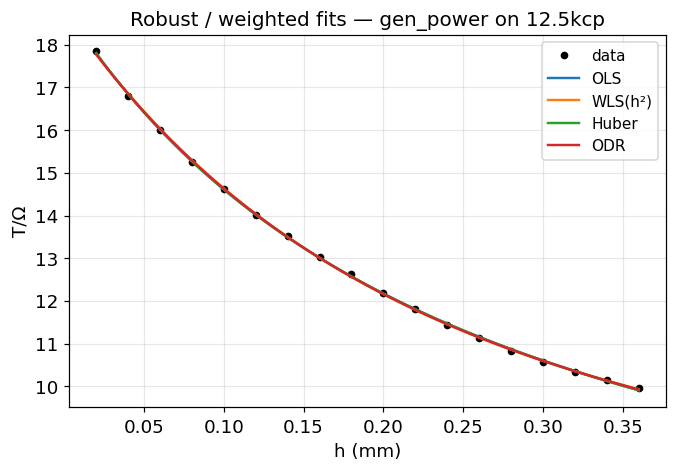

In [25]:
def weighted_fit(name: str, h, y, weight_fn: Callable[[np.ndarray], np.ndarray]) -> FitResult:
    w = np.asarray(weight_fn(np.asarray(h, float)), float)
    sigma = 1.0 / np.sqrt(np.clip(w, 1e-12, None))
    return fit_model(name, h, y, sigma=sigma)

def robust_fit(name: str, h, y, loss: str = "huber", f_scale: float = 1.0) -> FitResult:
    spec = MODELS[name]
    h = np.asarray(h, float); y = np.asarray(y, float)
    p0 = spec["p0"](h, y); lo, hi = spec["bounds"]
    def resid(p): return spec["func"](h, *p) - y
    try:
        res = optimize.least_squares(resid, p0, bounds=(lo, hi),
                                     loss=loss, f_scale=f_scale, max_nfev=20000)
        popt = res.x
        # crude covariance from Jacobian
        J = res.jac
        dof = max(len(y) - len(popt), 1)
        rss = np.sum(res.fun ** 2)
        pcov = np.linalg.pinv(J.T @ J) * (rss / dof)
        ok, msg = res.success, res.message
    except Exception as e:
        popt = np.array(p0); pcov = np.full((len(p0), len(p0)), np.nan); ok, msg = False, str(e)
    return FitResult(name=name, popt=popt, pcov=pcov, pnames=spec["pnames"],
                     func=spec["func"], h=h, y=y, method=f"robust-{loss}",
                     success=ok, message=msg)

def odr_fit(name: str, h, y, sx: float = 0.005, sy: Optional[float] = None) -> FitResult:
    """Orthogonal Distance Regression. sx = std on h (mm), sy = std on y."""
    spec = MODELS[name]
    h = np.asarray(h, float); y = np.asarray(y, float)
    if sy is None: sy = 0.02 * np.std(y) + 1e-9
    def f(B, x): return spec["func"](x, *B)
    model = odr.Model(f)
    data = odr.RealData(h, y, sx=sx, sy=sy)
    p0 = spec["p0"](h, y)
    out = odr.ODR(data, model, beta0=p0, maxit=200).run()
    return FitResult(name=name, popt=out.beta, pcov=out.cov_beta,
                     pnames=spec["pnames"], func=spec["func"], h=h, y=y,
                     method="odr", success=True, message=out.stopreason[0] if out.stopreason else "")

# Demo: gen_power model with three strategies
demo_name = "gen_power"
fit_ols   = fit_model(demo_name, h_f, y_f)
fit_wls   = weighted_fit(demo_name, h_f, y_f, weight_fn=lambda h: h ** 2)   # de-weight small h
fit_rob   = robust_fit(demo_name, h_f, y_f, loss="huber", f_scale=np.std(y_f) * 0.5)
fit_odr   = odr_fit(demo_name, h_f, y_f, sx=0.005)

robust_table = pd.DataFrame({k: v.as_series() for k, v in
                             {"OLS": fit_ols, "WLS(h²)": fit_wls,
                              "Huber": fit_rob, "ODR": fit_odr}.items()}).T
display(robust_table)

fig, ax = plt.subplots()
ax.plot(h_f, y_f, "ko", ms=4, label="data")
hh = np.linspace(h_f.min(), h_f.max(), 400)
for nm, fr, c in zip(["OLS", "WLS(h²)", "Huber", "ODR"],
                     [fit_ols, fit_wls, fit_rob, fit_odr],
                     ["C0", "C1", "C2", "C3"]):
    ax.plot(hh, fr.predict(hh), color=c, label=nm)
ax.set_xlabel("h (mm)"); ax.set_ylabel("T/Ω")
ax.set_title(f"Robust / weighted fits — {demo_name} on {FOCUS_SAMPLE}")
ax.legend()
save_fig(fig, "05_robust_weighted"); plt.show()


## 6. Residual analysis

A *good* model has residuals that are (i) zero-mean, (ii) homoscedastic, (iii)
independent of $h$, (iv) approximately Gaussian. We plot:

- residuals vs $h$
- residual histogram
- QQ plot
- residual autocorrelation
- standardized residuals (|z| > 2 flagged)

Helpers: `compute_residuals`, `plot_residuals`, `residual_statistics`.


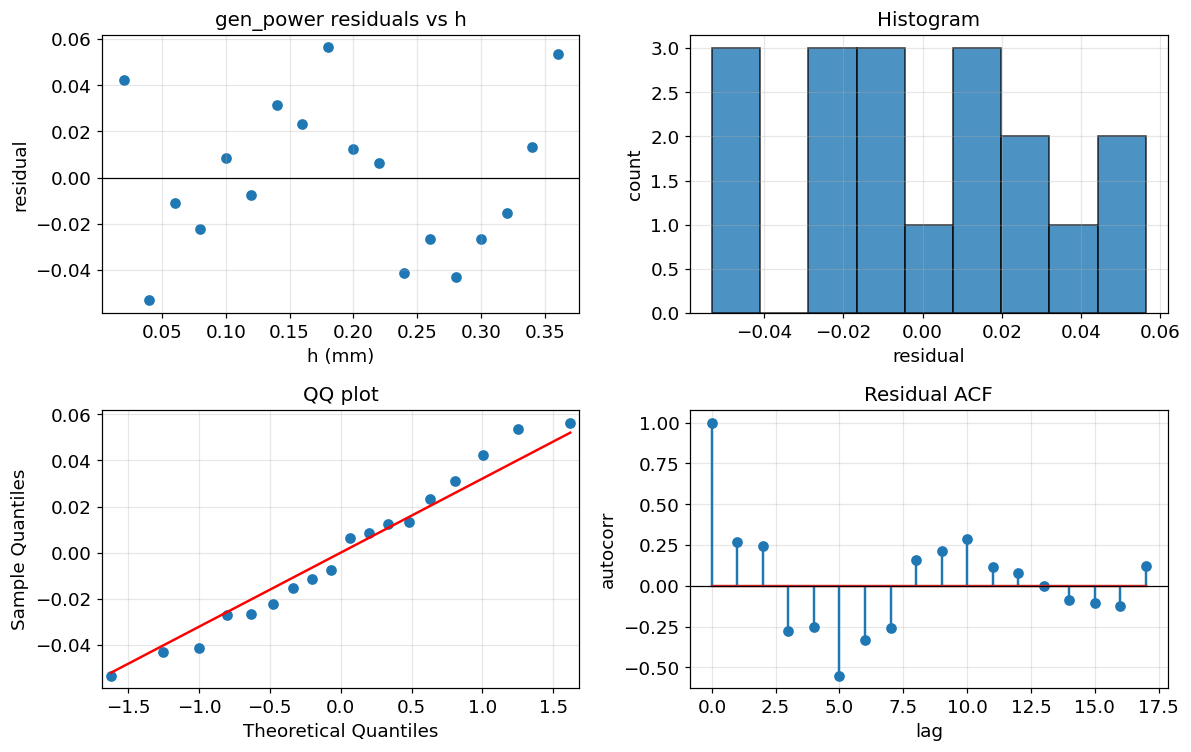

,mean,std,skew,kurtosis,shapiro_W,shapiro_p
hyperbolic,-1.613736e-10,1.333577,0.010580,-1.406056,0.931865,0.209395
regularized,-9.066821e-12,0.033055,0.147223,-0.943579,0.967228,0.744248
gen_power,6.024318e-08,0.033011,0.169107,-0.979559,0.965800,0.716052
saturation,1.042727e-09,0.190930,0.332852,-0.288187,0.976217,0.902898


In [26]:
def compute_residuals(fr: FitResult):
    r = fr.residuals
    return r, r / (np.std(r) + 1e-12)

def residual_statistics(r: np.ndarray) -> dict:
    sh = stats.shapiro(r) if 3 <= len(r) <= 5000 else (np.nan, np.nan)
    return {
        "mean": float(np.mean(r)),
        "std": float(np.std(r, ddof=1)),
        "skew": float(stats.skew(r)),
        "kurtosis": float(stats.kurtosis(r)),
        "shapiro_W": float(sh[0]) if sh[0] is not np.nan else np.nan,
        "shapiro_p": float(sh[1]) if sh[1] is not np.nan else np.nan,
    }

def plot_residuals(fr: FitResult, title_prefix: str = ""):
    h = fr.h; r, rz = compute_residuals(fr)
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    ax = axes[0, 0]
    ax.scatter(h, r, c="C0"); ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("h (mm)"); ax.set_ylabel("residual")
    ax.set_title(f"{title_prefix} residuals vs h")

    ax = axes[0, 1]
    ax.hist(r, bins=min(20, max(5, len(r) // 2)), color="C0", alpha=0.8, edgecolor="k")
    ax.set_xlabel("residual"); ax.set_ylabel("count"); ax.set_title("Histogram")

    ax = axes[1, 0]
    sm.qqplot(r, line="s", ax=ax)
    ax.set_title("QQ plot")

    ax = axes[1, 1]
    lags = min(20, len(r) - 1)
    ac = sm.tsa.acf(r, nlags=lags, fft=False)
    ax.stem(range(lags + 1), ac)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("lag"); ax.set_ylabel("autocorr"); ax.set_title("Residual ACF")

    plt.tight_layout()
    return fig

best_guess = fits["gen_power"] if fits["gen_power"].success else fits["regularized"]
fig = plot_residuals(best_guess, title_prefix=best_guess.name)
save_fig(fig, "06_residuals_best"); plt.show()

stats_tbl = pd.DataFrame({name: residual_statistics(fr.residuals) for name, fr in fits.items() if fr.success}).T
display(stats_tbl)

# Automatic narrative
r = best_guess.residuals
if np.any(np.abs(r[:3]) > 3 * np.std(r)):
    print("⚠ Large residuals at the smallest gaps — model may underfit the divergence region.")
if abs(stats.skew(r)) > 1:
    print("⚠ Strongly skewed residuals — consider robust loss or different model.")
if np.corrcoef(best_guess.h, r)[0, 1] ** 2 > 0.2:
    print("⚠ Residuals correlate with h — systematic curvature unmodeled.")


## 7. Model comparison

$R^2$ rewards complexity. We use information criteria and cross-validation as well:

- **RMSE / MAE**: scale-aware error,
- **R² / adjusted R²**: fraction of variance explained,
- **AIC / BIC**: penalised likelihood,
- **K-fold CV RMSE**: out-of-sample predictive accuracy.

Helpers: `compute_metrics`, `compare_models`.


In [27]:
def compute_metrics(fr: FitResult, k_folds: int = 5) -> dict:
    y = fr.y; h = fr.h; n = len(y); k = len(fr.popt)
    yhat = fr.predict(h); r = y - yhat
    rss = float(np.sum(r ** 2)); tss = float(np.sum((y - y.mean()) ** 2))
    rmse = float(np.sqrt(rss / n)); mae = float(np.mean(np.abs(r)))
    r2 = 1 - rss / tss if tss > 0 else np.nan
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(n - k - 1, 1)
    sigma2 = rss / n
    aic = n * np.log(sigma2 + 1e-30) + 2 * k
    bic = n * np.log(sigma2 + 1e-30) + k * np.log(n)

    # K-fold CV
    cv_errs = []
    if n >= k_folds + len(fr.popt) + 1:
        kf = KFold(n_splits=k_folds, shuffle=True, random_state=0)
        for tr, te in kf.split(h):
            try:
                fr_cv = fit_model(fr.name, h[tr], y[tr])
                cv_errs.append(np.sqrt(np.mean((y[te] - fr_cv.predict(h[te])) ** 2)))
            except Exception:
                pass
    cv_rmse = float(np.mean(cv_errs)) if cv_errs else np.nan

    return {"n": n, "k": k, "RMSE": rmse, "MAE": mae, "R2": r2,
            "adjR2": adj_r2, "AIC": aic, "BIC": bic, "CV_RMSE": cv_rmse}

def compare_models(fits_dict: Dict[str, FitResult]) -> pd.DataFrame:
    rows = {name: compute_metrics(fr) for name, fr in fits_dict.items() if fr.success}
    df = pd.DataFrame(rows).T
    df = df.sort_values("AIC")
    df["ΔAIC"] = df["AIC"] - df["AIC"].min()
    df["ΔBIC"] = df["BIC"] - df["BIC"].min()
    return df

comparison = compare_models(fits)
display(comparison.round(4))

best_pred  = comparison["CV_RMSE"].idxmin() if comparison["CV_RMSE"].notna().any() else comparison["RMSE"].idxmin()
best_aic   = comparison["AIC"].idxmin()
print(f"Best predictive (CV-RMSE) : {best_pred}")
print(f"Best AIC (parsimony)      : {best_aic}")


,n,k,RMSE,MAE,R2,adjR2,AIC,BIC,CV_RMSE,ΔAIC,ΔBIC
regularized,18.0,3.0,0.0321,0.0272,0.9998,0.9998,-117.7733,-115.1022,0.0407,0.0000,0.0000
gen_power,18.0,4.0,0.0321,0.0275,0.9998,0.9998,-115.8221,-112.2606,0.0496,1.9513,2.8416
saturation,18.0,3.0,0.1856,0.1533,0.9937,0.9924,-54.6394,-51.9683,0.2738,63.1339,63.1339
hyperbolic,18.0,2.0,1.2960,1.1582,0.6947,0.6540,13.3343,15.1150,1.9964,131.1076,130.2172


Best predictive (CV-RMSE) : regularized
Best AIC (parsimony)      : regularized


## 8. Low-gap sensitivity analysis

The model parameters — especially $A$ and the inferred viscosity — should be
**stable** when the smallest-gap points are removed. If the answer swings wildly,
the result is dominated by ill-conditioned near-contact data and a regularized
model with $h_0$ is required.


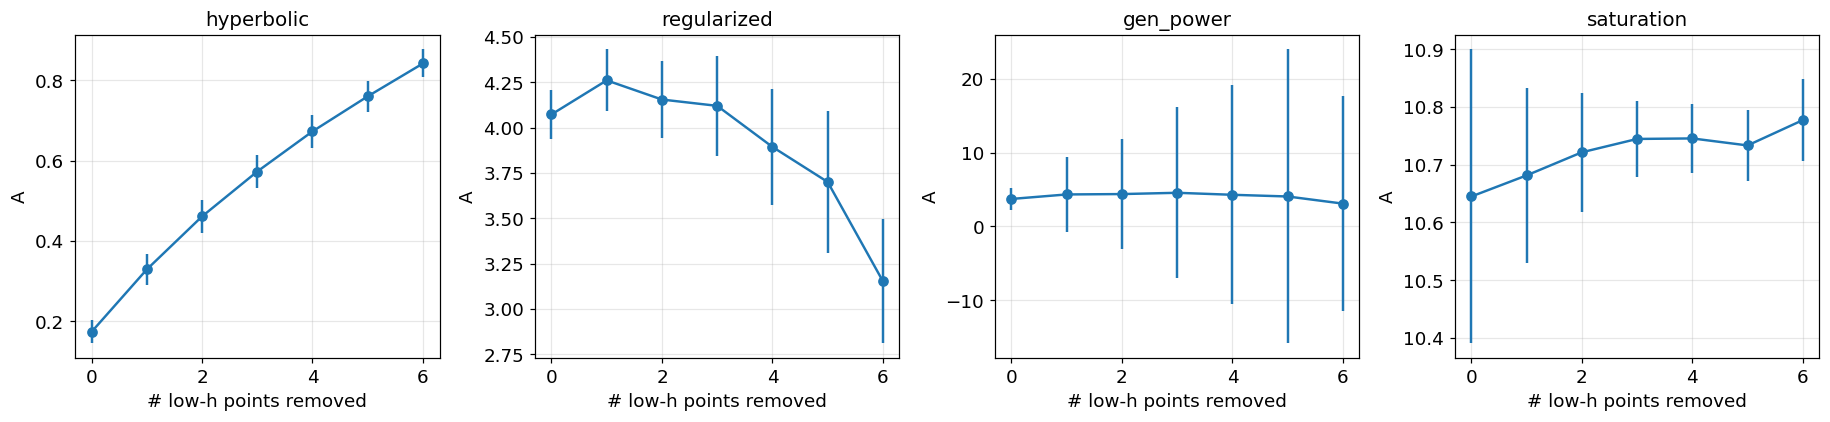

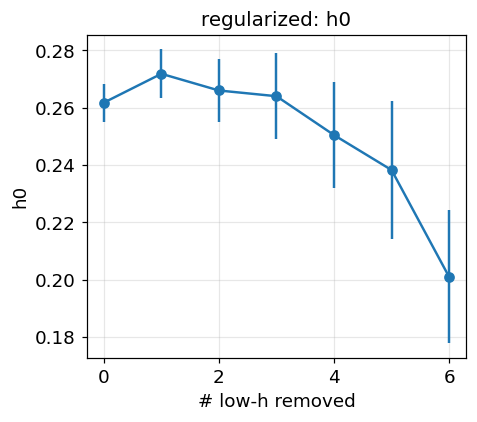

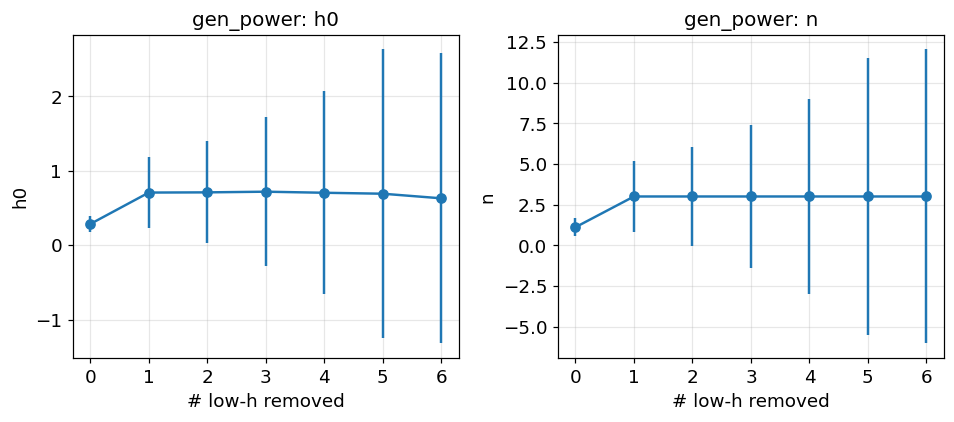

hyperbolic      CV(A) over removals = 0.439
regularized     CV(A) over removals = 0.098
gen_power       CV(A) over removals = 0.124
saturation      CV(A) over removals = 0.004


In [28]:
def remove_low_gap_points(h, y, k: int) -> Tuple[np.ndarray, np.ndarray]:
    order = np.argsort(h)
    keep = order[k:]
    return np.asarray(h)[keep], np.asarray(y)[keep]

def sensitivity_analysis(h, y, model_name: str, max_remove: int = 6) -> pd.DataFrame:
    rows = []
    for k in range(0, max_remove + 1):
        hk, yk = remove_low_gap_points(h, y, k)
        if len(hk) < len(MODELS[model_name]["pnames"]) + 1:
            break
        fr = fit_model(model_name, hk, yk)
        row = {"removed": k, "n_used": len(hk)}
        for n, v, s in zip(fr.pnames, fr.popt, fr.perr):
            row[n] = v; row[f"{n}_se"] = s
        rows.append(row)
    return pd.DataFrame(rows)

sens_tables = {name: sensitivity_analysis(h_f, y_f, name) for name in MODELS}

# Plot stability of the slope/A parameter for each model
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.2 * len(MODELS), 4), sharex=True)
for ax, (name, tbl) in zip(axes, sens_tables.items()):
    ax.errorbar(tbl["removed"], tbl["A"], yerr=tbl["A_se"], fmt="o-", color="C0")
    ax.set_title(name); ax.set_xlabel("# low-h points removed"); ax.set_ylabel("A")
plt.tight_layout()
save_fig(fig, "08_sensitivity_A"); plt.show()

# Also plot h0/n where applicable
for name in ["regularized", "gen_power"]:
    tbl = sens_tables[name]
    cols = [c for c in ["h0", "n"] if c in tbl.columns]
    fig, axes = plt.subplots(1, len(cols), figsize=(4.5 * len(cols), 4))
    if len(cols) == 1: axes = [axes]
    for ax, c in zip(axes, cols):
        ax.errorbar(tbl["removed"], tbl[c], yerr=tbl[f"{c}_se"], fmt="o-")
        ax.set_xlabel("# low-h removed"); ax.set_ylabel(c); ax.set_title(f"{name}: {c}")
    plt.tight_layout(); save_fig(fig, f"08_sensitivity_{name}"); plt.show()

for name, tbl in sens_tables.items():
    cv_A = tbl["A"].std() / abs(tbl["A"].mean() + 1e-12)
    print(f"{name:<14s}  CV(A) over removals = {cv_A:.3f}")


## 9. Uncertainty quantification — bootstrap (and optional MCMC)

Bootstrap resamples the data (rows) with replacement, refits, and aggregates the
parameter distributions. This is robust to model misspecification of the noise
structure. Optional MCMC (via `emcee`) is included as a Bayesian alternative when
the package is available.


Bootstrap on 'regularized'  (n=400 successful resamples)


,median,ci95_lo,ci95_hi,std
A,4.087759,3.864856,4.590020,0.193565
h0,0.262597,0.251381,0.286155,0.009550
B,3.333353,2.758527,3.600963,0.225114


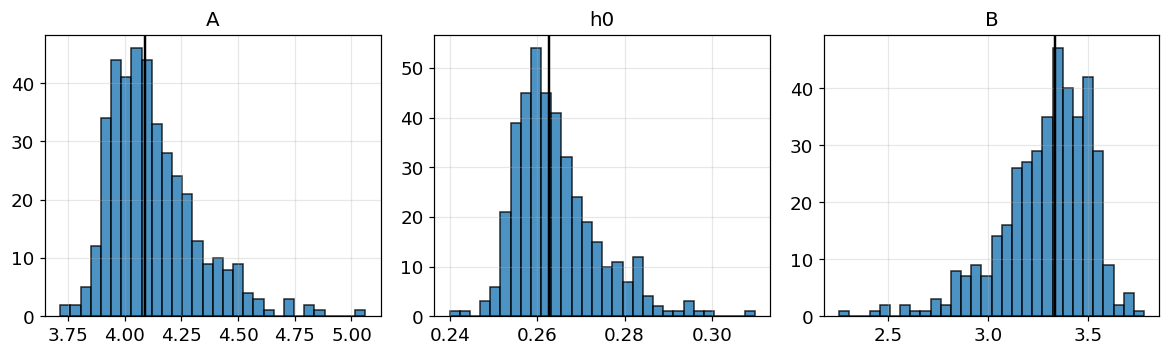

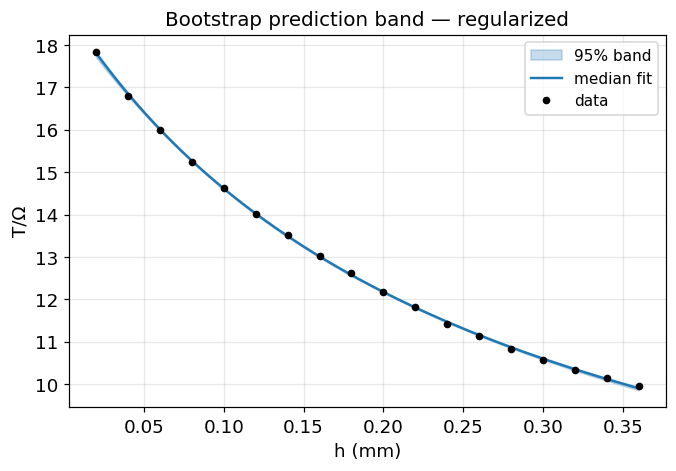

In [29]:
def bootstrap_fit(model_name: str, h, y, n_boot: int = 500,
                  random_state: int = 0) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    h = np.asarray(h); y = np.asarray(y); n = len(h)
    rows = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            fr = fit_model(model_name, h[idx], y[idx])
            if fr.success:
                rows.append(dict(zip(fr.pnames, fr.popt)))
        except Exception:
            continue
    return pd.DataFrame(rows)

def parameter_confidence_intervals(boot_df: pd.DataFrame, level: float = 0.95) -> pd.DataFrame:
    lo, hi = (1 - level) / 2, 1 - (1 - level) / 2
    return pd.DataFrame({
        "median": boot_df.median(),
        f"ci{int(level*100)}_lo": boot_df.quantile(lo),
        f"ci{int(level*100)}_hi": boot_df.quantile(hi),
        "std": boot_df.std(),
    })

boot_name = best_aic  # use the parsimoniously best model
boot = bootstrap_fit(boot_name, h_f, y_f, n_boot=400)
ci   = parameter_confidence_intervals(boot)
print(f"Bootstrap on '{boot_name}'  (n={len(boot)} successful resamples)")
display(ci)

# Parameter distributions
fig, axes = plt.subplots(1, boot.shape[1], figsize=(3.6 * boot.shape[1], 3.4))
if boot.shape[1] == 1: axes = [axes]
for ax, col in zip(axes, boot.columns):
    ax.hist(boot[col], bins=30, color="C0", alpha=0.8, edgecolor="k")
    ax.axvline(ci.loc[col, "median"], color="k")
    ax.set_title(col)
plt.tight_layout()
save_fig(fig, "09_bootstrap_hists"); plt.show()

# Predictive confidence band
hh = np.linspace(h_f.min(), h_f.max(), 300)
preds = np.array([MODELS[boot_name]["func"](hh, *row) for row in boot.values])
band_lo, band_hi = np.percentile(preds, [2.5, 97.5], axis=0)
median = np.percentile(preds, 50, axis=0)

fig, ax = plt.subplots()
ax.fill_between(hh, band_lo, band_hi, alpha=0.25, color="C0", label="95% band")
ax.plot(hh, median, "C0", label="median fit")
ax.plot(h_f, y_f, "ko", ms=4, label="data")
ax.set_xlabel("h (mm)"); ax.set_ylabel("T/Ω")
ax.set_title(f"Bootstrap prediction band — {boot_name}")
ax.legend(); save_fig(fig, "09_bootstrap_band"); plt.show()


In [30]:
# --- Optional Bayesian MCMC (only runs if emcee is installed) --------------
if HAS_EMCEE:
    import emcee
    def log_prob(theta, h, y, model):
        if np.any(np.array(theta[:-1]) <= 0):  # positivity for first params
            return -np.inf
        sigma = max(theta[-1], 1e-6)
        try:
            pred = model(h, *theta[:-1])
        except Exception:
            return -np.inf
        return -0.5 * np.sum(((y - pred) / sigma) ** 2 + np.log(2 * np.pi * sigma ** 2))

    spec = MODELS[boot_name]
    p0 = list(spec["p0"](h_f, y_f)) + [np.std(y_f) * 0.1]
    nwalk, ndim = 32, len(p0)
    pos = p0 + 1e-3 * np.random.randn(nwalk, ndim) * (np.abs(p0) + 1e-6)
    sampler = emcee.EnsembleSampler(nwalk, ndim, log_prob, args=(h_f, y_f, spec["func"]))
    sampler.run_mcmc(pos, 1500, progress=False)
    chain = sampler.get_chain(discard=500, flat=True)
    mcmc_df = pd.DataFrame(chain, columns=spec["pnames"] + ["sigma"])
    display(parameter_confidence_intervals(mcmc_df))
else:
    print("emcee not installed — skipping MCMC. (pip install emcee to enable.)")


emcee not installed — skipping MCMC. (pip install emcee to enable.)


## 10. Final scientific interpretation

Parameter interpretation (with the recommended model):

- **$A$** is proportional to the apparent viscosity through the geometry constant.
  Comparing $A$ across samples gives a direct viscosity ranking.
- **$h_0$** is the effective gap-zero offset. A non-zero $h_0$ ($\sim 10\text{–}100\,\mu m$)
  is the fingerprint of slip / asperity / compliance.
- **$n$** ≠ 1 in the generalized model signals departure from classical Newtonian
  lubrication. $n<1$ is typical of shear-thinning; $n>1$ of squeeze-film effects.
- **$B$** is the parasitic baseline (bearings, air drag, instrument offset).

Plausible physical mechanisms behind a non-ideal $h_0$/$n$:
slip at the solid–fluid interface, surface roughness (asperity contact),
plate compliance under torque, steric / depletion layers of polymer chains,
viscoelastic stress build-up.


In [31]:
# Build a publication-ready summary table for the focus sample
def build_summary(fits_dict, comparison, boot_df, model_name) -> pd.DataFrame:
    fr = fits_dict[model_name]
    base = summarize_fit(fr).set_index("param")
    metrics = pd.Series(compute_metrics(fr), name="metric")
    boot_ci = parameter_confidence_intervals(boot_df) if boot_df is not None else None
    return base, metrics, boot_ci

base_tbl, metrics_tbl, boot_ci = build_summary(fits, comparison, boot, best_aic)
print(f"### Recommended model: {best_aic}\n")
display(base_tbl)
print("\nGoodness of fit:"); display(metrics_tbl.to_frame())
if boot_ci is not None:
    print("\nBootstrap 95% CIs:"); display(boot_ci)

# Export
base_tbl.to_csv(OUT_DIR / f"params_{FOCUS_SAMPLE}_{best_aic}.csv")
metrics_tbl.to_csv(OUT_DIR / f"metrics_{FOCUS_SAMPLE}_{best_aic}.csv")
if boot_ci is not None:
    boot_ci.to_csv(OUT_DIR / f"bootstrap_{FOCUS_SAMPLE}_{best_aic}.csv")
comparison.to_csv(OUT_DIR / f"model_comparison_{FOCUS_SAMPLE}.csv")
print(f"\nExports written to {OUT_DIR.resolve()}")

# Narrative
narr = []
A = fits[best_aic].popt[0]
narr.append(f"On sample {FOCUS_SAMPLE}, the best model is **{best_aic}** "
            f"(ΔAIC over runner-up = {comparison['ΔAIC'].iloc[1]:.2f}).")
if "h0" in fits[best_aic].pnames:
    h0 = fits[best_aic].popt[fits[best_aic].pnames.index("h0")]
    narr.append(f"The regularization length h0 ≈ {h0*1000:.1f} µm is non-negligible, "
                "consistent with a finite slip / compliance / gap-zero offset.")
if "n" in fits[best_aic].pnames:
    n = fits[best_aic].popt[fits[best_aic].pnames.index("n")]
    narr.append(f"The exponent n ≈ {n:.2f} {'departs from' if abs(n-1)>0.1 else 'is consistent with'} "
                f"classical 1/h lubrication.")
narr.append(f"Coefficient A ≈ {A:.3g} encodes the apparent viscosity through the geometry constant.")
print("\n".join(narr))


### Recommended model: regularized



,value,stderr,ci95_lo,ci95_hi
param,,,,
A,4.073240,0.135735,3.807198,4.339281
h0,0.261785,0.006597,0.248855,0.274714
B,3.350670,0.163545,3.030122,3.671218



Goodness of fit:


,metric
n,18.000000
k,3.000000
RMSE,0.032124
MAE,0.027246
R2,0.999812
adjR2,0.999772
AIC,-117.773337
BIC,-115.102222
CV_RMSE,0.040660



Bootstrap 95% CIs:


,median,ci95_lo,ci95_hi,std
A,4.087759,3.864856,4.590020,0.193565
h0,0.262597,0.251381,0.286155,0.009550
B,3.333353,2.758527,3.600963,0.225114



Exports written to C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\results\Auto-runs\outputs_rheology
On sample 12.5kcp, the best model is **regularized** (ΔAIC over runner-up = 1.95).
The regularization length h0 ≈ 261.8 µm is non-negligible, consistent with a finite slip / compliance / gap-zero offset.
Coefficient A ≈ 4.07 encodes the apparent viscosity through the geometry constant.


## 11. Publication-quality figure
A clean two-panel figure: (left) data + best fit with 95 % band; (right) residuals.


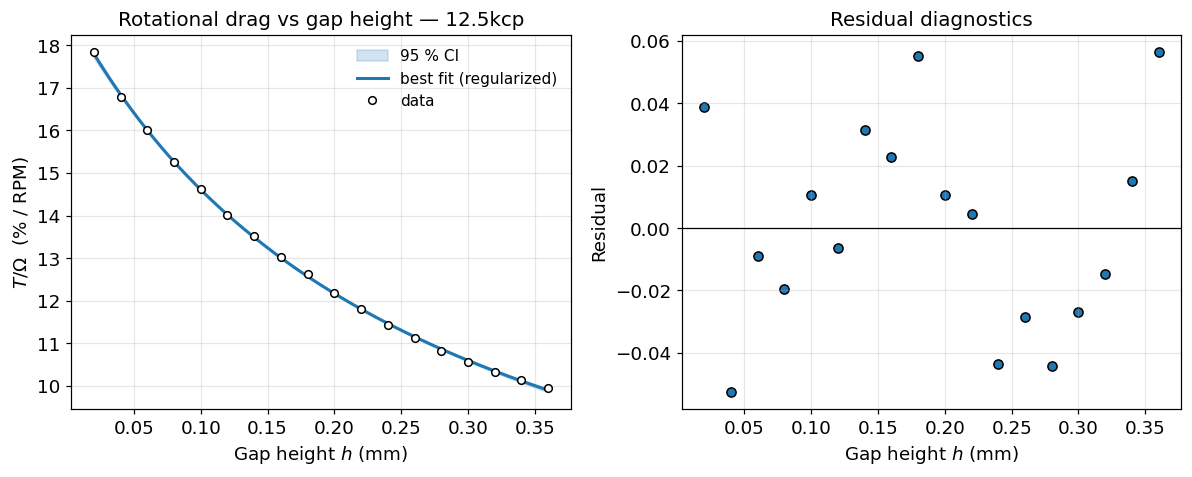

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.fill_between(hh, band_lo, band_hi, alpha=0.20, color="#1f77b4", label="95 % CI")
ax.plot(hh, median, color="#1f77b4", lw=2, label=f"best fit ({boot_name})")
ax.plot(h_f, y_f, "o", ms=5, mfc="white", mec="k", label="data")
ax.set_xlabel("Gap height $h$ (mm)")
ax.set_ylabel(r"$T/\Omega$  ({})".format(Y_UNIT))
ax.set_title(f"Rotational drag vs gap height — {FOCUS_SAMPLE}")
ax.legend(frameon=False)

ax = axes[1]
r = fits[boot_name].residuals
ax.axhline(0, color="k", lw=0.8)
ax.scatter(h_f, r, color="#1f77b4", edgecolor="k")
ax.set_xlabel("Gap height $h$ (mm)")
ax.set_ylabel("Residual")
ax.set_title("Residual diagnostics")

plt.tight_layout()
save_fig(fig, "11_publication_main")
plt.show()


## 12. Optional advanced analyses

- **Spline fit** as a non-parametric reference for the trend.
- **Automatic regime segmentation** via local-slope change-points.
- **Multi-sample sweep**: fit the recommended model to every sample in the dataset
  and tabulate $A$, $h_0$, $n$ → viscosity ranking.


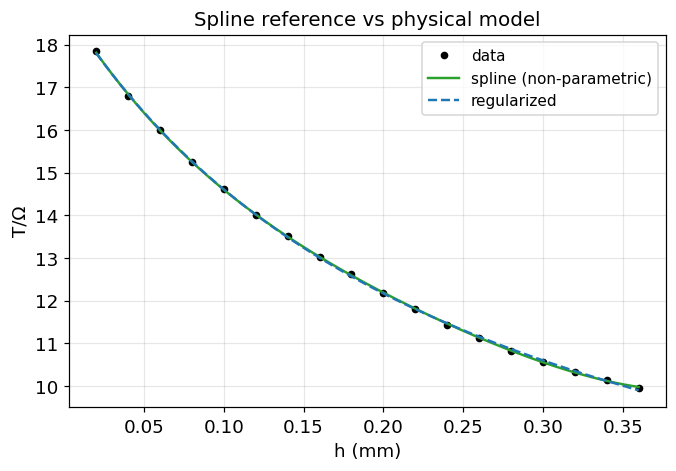

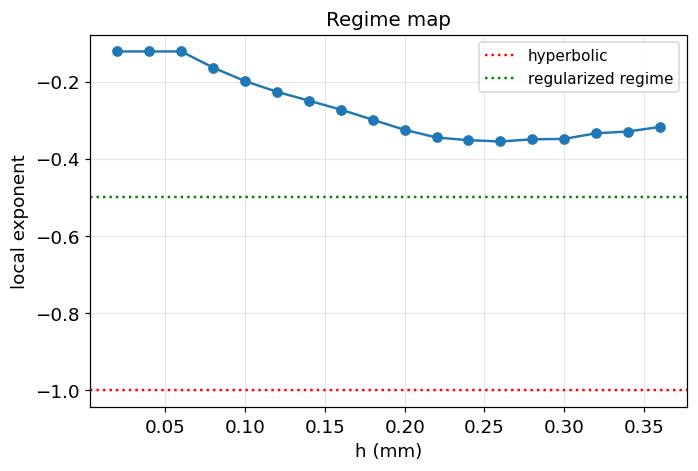

In [33]:
from scipy.interpolate import UnivariateSpline

def spline_fit(h, y, s=None):
    order = np.argsort(h); h, y = np.asarray(h)[order], np.asarray(y)[order]
    spl = UnivariateSpline(h, y, k=4, s=s if s is not None else len(h) * np.var(y) * 0.001)
    return spl

spl = spline_fit(h_f, y_f)
hh = np.linspace(h_f.min(), h_f.max(), 400)

fig, ax = plt.subplots()
ax.plot(h_f, y_f, "ko", ms=4, label="data")
ax.plot(hh, spl(hh), "C2", label="spline (non-parametric)")
ax.plot(hh, fits[boot_name].predict(hh), "C0--", label=f"{boot_name}")
ax.set_xlabel("h (mm)"); ax.set_ylabel("T/Ω")
ax.set_title("Spline reference vs physical model")
ax.legend(); save_fig(fig, "12_spline_vs_model"); plt.show()

# Regime segmentation: local slope crossing of -0.5 and -1
h_l, slopes = compute_local_slope(h_f, y_f, window=5)
fig, ax = plt.subplots()
ax.plot(h_l, slopes, "o-"); ax.axhline(-1, ls=":", color="r", label="hyperbolic")
ax.axhline(-0.5, ls=":", color="g", label="regularized regime")
ax.set_xlabel("h (mm)"); ax.set_ylabel("local exponent")
ax.set_title("Regime map"); ax.legend()
save_fig(fig, "12_regime_map"); plt.show()


,sample,n_pts,model,success,RMSE,R2,AIC,A,A_se,h0,h0_se,B,B_se,visc_kcp
0,1kcp,16,regularized,True,0.002299,0.999835,-188.404666,0.412083,0.016796,0.310658,0.008958,0.144647,0.018507,1.0
1,2kcp,16,regularized,True,0.011844,0.999515,-135.950244,1.021634,0.065150,0.270524,0.012613,0.650428,0.079254,2.0
2,4kcp,21,regularized,True,0.015913,0.999794,-167.907040,2.173531,0.067972,0.299551,0.007086,1.047132,0.071437,4.0
3,5kcp,17,regularized,True,0.038092,0.998325,-105.103631,1.522600,0.157130,0.246290,0.019275,1.326292,0.200644,5.0
4,8kcp,19,regularized,True,0.016495,0.999876,-149.977621,2.609906,0.067068,0.268600,0.005248,1.980443,0.078179,8.0
5,10kcp,21,regularized,True,0.066299,0.998279,-107.970188,2.804208,0.241017,0.275368,0.018289,2.558299,0.268258,10.0
6,12.5kcp,18,regularized,True,0.032124,0.999812,-117.773337,4.073240,0.135735,0.261785,0.006597,3.350670,0.163545,12.5
7,15kcp,11,regularized,True,0.158089,0.994846,-34.581129,4.697404,1.599525,0.259470,0.060494,6.405955,2.198410,15.0
8,20kcp,17,regularized,True,0.059862,0.999788,-89.734308,6.450813,0.232229,0.238557,0.006566,5.948699,0.303064,20.0
9,25kcp,23,regularized,True,0.084276,0.999640,-107.788196,7.147239,0.244645,0.262929,0.007188,4.234322,0.273128,25.0


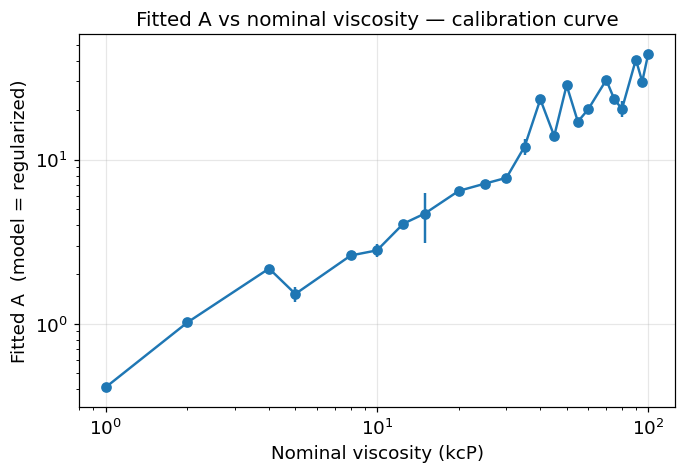

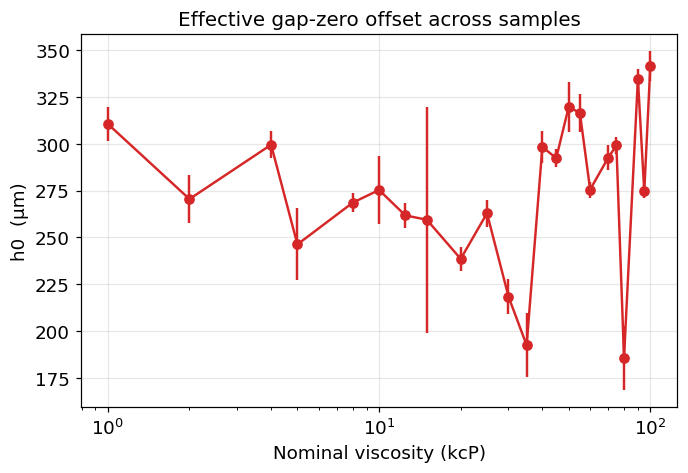

In [34]:
# Multi-sample sweep
def fit_all_samples(tidy_df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    out = []
    for s, sub in tidy_df.groupby("sample"):
        sub = sub.dropna(subset=["h_mm", "T_over_RPM"])
        if len(sub) < len(MODELS[model_name]["pnames"]) + 1:
            continue
        fr = fit_model(model_name, sub["h_mm"].values, sub["T_over_RPM"].values)
        m = compute_metrics(fr)
        row = {"sample": s, "n_pts": len(sub), "model": model_name,
               "success": fr.success, "RMSE": m["RMSE"], "R2": m["R2"], "AIC": m["AIC"]}
        for n, v, se in zip(fr.pnames, fr.popt, fr.perr):
            row[n] = v; row[f"{n}_se"] = se
        out.append(row)
    df = pd.DataFrame(out)
    # numeric viscosity for sorting
    df["visc_kcp"] = df["sample"].str.replace("kcp", "", regex=False).astype(float)
    return df.sort_values("visc_kcp").reset_index(drop=True)

sweep = fit_all_samples(tidy, best_aic)
display(sweep.head(10))
sweep.to_csv(OUT_DIR / f"sweep_{best_aic}.csv", index=False)

# A vs nominal viscosity
fig, ax = plt.subplots()
ax.errorbar(sweep["visc_kcp"], sweep["A"], yerr=sweep["A_se"], fmt="o-")
ax.set_xlabel("Nominal viscosity (kcP)")
ax.set_ylabel(f"Fitted A  (model = {best_aic})")
ax.set_title("Fitted A vs nominal viscosity — calibration curve")
ax.set_xscale("log"); ax.set_yscale("log")
save_fig(fig, "12_A_vs_viscosity"); plt.show()

# h0 trend, if present
if "h0" in sweep.columns:
    fig, ax = plt.subplots()
    ax.errorbar(sweep["visc_kcp"], sweep["h0"] * 1000, yerr=sweep["h0_se"] * 1000, fmt="o-", color="C3")
    ax.set_xlabel("Nominal viscosity (kcP)"); ax.set_ylabel("h0  (µm)")
    ax.set_title("Effective gap-zero offset across samples")
    ax.set_xscale("log")
    save_fig(fig, "12_h0_vs_viscosity"); plt.show()


## Conclusion & key scientific reminders

1. Pure $1/h$ divergence is rarely physically valid right up to contact.
2. Regularized hyperbolic / generalized-power models with a non-zero $h_0$ are usually
   more physically meaningful.
3. Gap-height uncertainty dominates at small $h$ — use ODR or weight $h^2$ if in doubt.
4. Residual diagnostics are mandatory — high $R^2$ alone does **not** validate a fit.
5. Stability under removal of low-gap points is the cleanest test of model robustness.
6. Always fit in physical space, not in log/inverse space.
7. Cross-validation and AIC/BIC together protect against overfitting.

All exported tables and figures are in `outputs_rheology/` and `figures_rheology/`.
